In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# Unzip the dataset
zip_path = "/content/archive (4).zip"
extract_path = "/content/ecommerce_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Show the extracted files
os.listdir(extract_path)

['sales_cleaned.csv',
 'orders.csv',
 'order_items.csv',
 'products.csv',
 'customers.csv']

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4) (1).zip


In [ ]:
customers = pd.read_csv("/content/ecommerce_data/customers.csv")
orders = pd.read_csv("/content/ecommerce_data/orders.csv")
order_items = pd.read_csv("/content/ecommerce_data/order_items.csv")
products = pd.read_csv("/content/ecommerce_data/products.csv")
sales = pd.read_csv("/content/ecommerce_data/sales_cleaned.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Sales:", sales.shape)

Customers: (300, 3)
Orders: (1000, 4)
Order Items: (2000, 4)
Products: (50, 3)
Sales: (1625, 10)


In [ ]:
sales.head()

,order_id,product_id,quantity,price,Revenue,customer_id,order_date,status,year,month
0,290,18,2,93,186,256,2024-08-26,Completed,2024,8
1,290,20,4,102,408,256,2024-08-26,Completed,2024,8
2,290,19,1,25,25,256,2024-08-26,Completed,2024,8
3,295,16,2,27,54,54,2024-06-25,Completed,2024,6
4,295,13,3,48,144,54,2024-06-25,Completed,2024,6


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     1625 non-null   int64 
 1   product_id   1625 non-null   int64 
 2   quantity     1625 non-null   int64 
 3   price        1625 non-null   int64 
 4   Revenue      1625 non-null   int64 
 5   customer_id  1625 non-null   int64 
 6   order_date   1625 non-null   object
 7   status       1625 non-null   object
 8   year         1625 non-null   int64 
 9   month        1625 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 127.1+ KB


In [ ]:
sales.isnull().sum()

,0
order_id,0
product_id,0
quantity,0
price,0
Revenue,0
customer_id,0
order_date,0
status,0
year,0
month,0


In [ ]:
sales.duplicated().sum()

np.int64(0)

In [ ]:
# Key Business Metrics

total_revenue = sales["Revenue"].sum()
total_orders = sales["order_id"].nunique()
total_customers = sales["customer_id"].nunique()
total_products = sales["product_id"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 311111
Total Orders: 695
Total Customers: 267
Total Products: 50
Average Order Value: 447.64


In [ ]:
# Monthly Revenue Analysis

sales["order_date"] = pd.to_datetime(sales["order_date"])

monthly_revenue = (
    sales.groupby(sales["order_date"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["order_date"] = monthly_revenue["order_date"].astype(str)

monthly_revenue

,order_date,Revenue
0,2024-01,30948
1,2024-02,23299
2,2024-03,27014
3,2024-04,27839
4,2024-05,22961
5,2024-06,22819
6,2024-07,24119
7,2024-08,27371
8,2024-09,23332
9,2024-10,30860


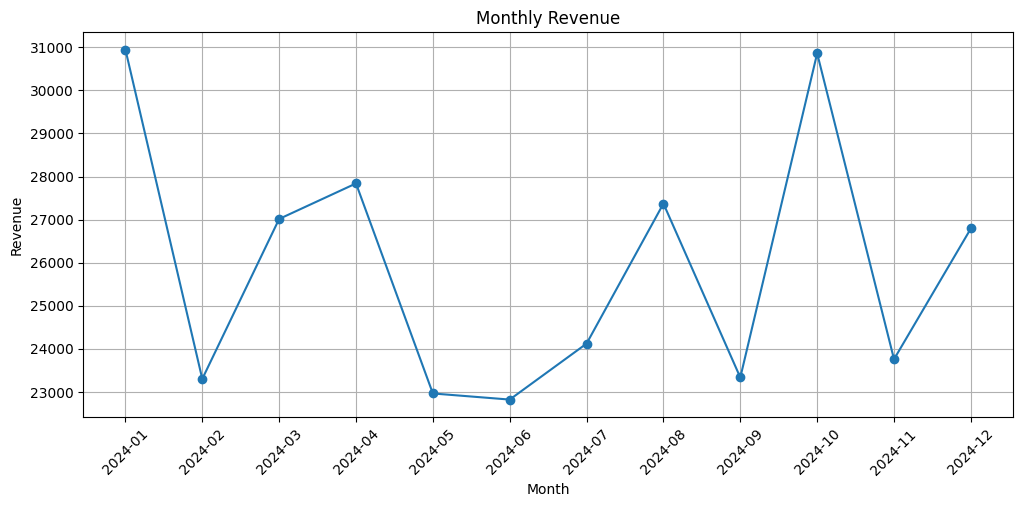

In [ ]:
# Plot Monthly Revenue

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Merge sales data with product information

sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products.head()

,order_id,product_id,quantity,price,Revenue,customer_id,order_date,status,year,month,product_name,category
0,290,18,2,93,186,256,2024-08-26,Completed,2024,8,Product_18,Makeup
1,290,20,4,102,408,256,2024-08-26,Completed,2024,8,Product_20,Hair
2,290,19,1,25,25,256,2024-08-26,Completed,2024,8,Product_19,Makeup
3,295,16,2,27,54,54,2024-06-25,Completed,2024,6,Product_16,Makeup
4,295,13,3,48,144,54,2024-06-25,Completed,2024,6,Product_13,Skin


In [ ]:
# Revenue by Category

category_revenue = (
    sales_products
    .groupby("category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,Revenue
category,
Hair,101637
Makeup,81085
Body,76011
Skin,52378


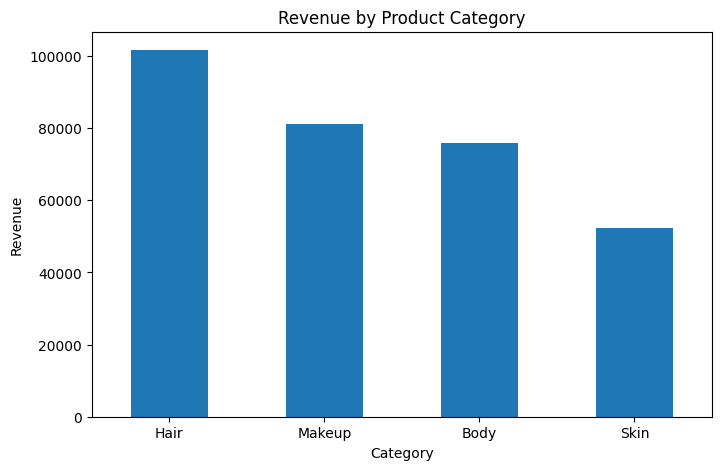

In [ ]:
# Revenue by Category Chart

category_revenue.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Top 10 Products by Revenue

top_products = (
    sales_products
    .groupby(["product_id", "product_name"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,,Revenue
product_id,product_name,
16,Product_16,9732
45,Product_45,9644
25,Product_25,9527
23,Product_23,9426
6,Product_6,8661
47,Product_47,8119
13,Product_13,8065
4,Product_4,7788
32,Product_32,7735


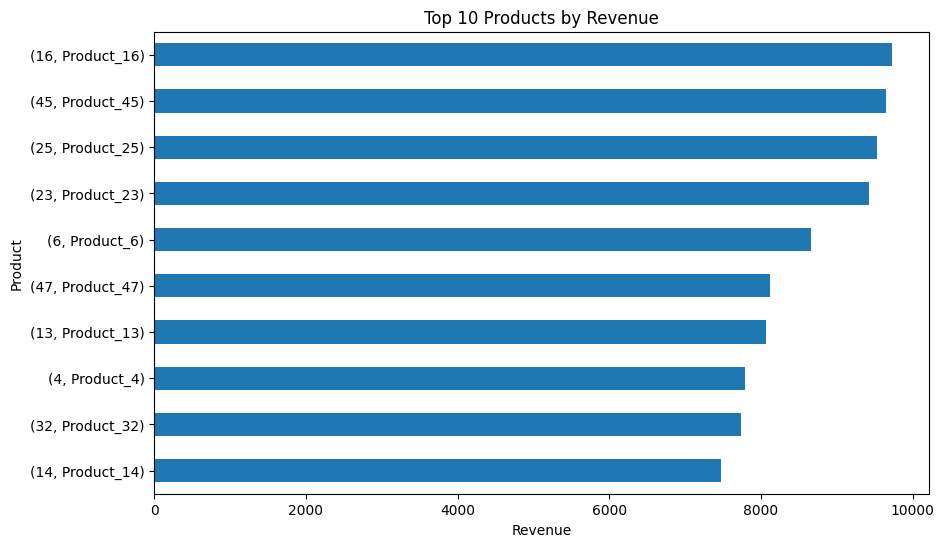

In [ ]:
# Top 10 Products Chart

top_products.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [ ]:
product_performance = (
    sales_products
    .groupby(["product_id", "product_name"])
    .agg(
        revenue=("Revenue", "sum"),
        units_sold=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

product_performance.head(10)

,,revenue,units_sold,orders
product_id,product_name,,,
16,Product_16,9732,135,44
45,Product_45,9644,154,44
25,Product_25,9527,131,38
23,Product_23,9426,132,46
6,Product_6,8661,132,40
47,Product_47,8119,128,40
13,Product_13,8065,113,37
4,Product_4,7788,120,37
32,Product_32,7735,131,38


In [ ]:
# Merge sales with customer information

sales_customers = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

sales_customers.head()

,order_id,product_id,quantity,price,Revenue,customer_id,order_date,status,year,month,country,signup_date
0,290,18,2,93,186,256,2024-08-26,Completed,2024,8,Germany,2023-06-03
1,290,20,4,102,408,256,2024-08-26,Completed,2024,8,Germany,2023-06-03
2,290,19,1,25,25,256,2024-08-26,Completed,2024,8,Germany,2023-06-03
3,295,16,2,27,54,54,2024-06-25,Completed,2024,6,Morocco,2023-06-12
4,295,13,3,48,144,54,2024-06-25,Completed,2024,6,Morocco,2023-06-12


In [ ]:
# Revenue by Country

country_revenue = (
    sales_customers
    .groupby("country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue

,Revenue
country,
Italy,70719
Spain,69897
Morocco,65164
France,55976
Germany,49355


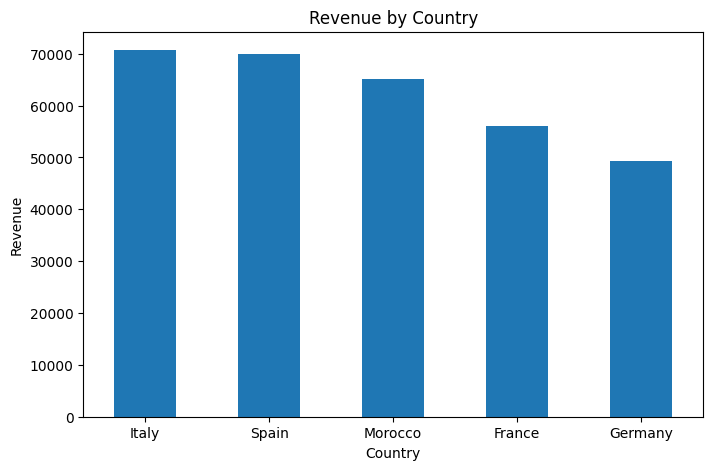

In [ ]:
# Revenue by Country Chart

country_revenue.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# Top 10 Customers by Revenue

top_customers = (
    sales_customers
    .groupby("customer_id")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,Revenue
customer_id,
13,5048
39,4564
152,4309
144,3420
76,3330
113,2960
126,2960
130,2949
277,2939


In [ ]:
# Customer Performance

customer_performance = (
    sales_customers
    .groupby("customer_id")
    .agg(
        revenue=("Revenue", "sum"),
        orders=("order_id", "nunique")
    )
)

customer_performance["average_order_value"] = (
    customer_performance["revenue"] /
    customer_performance["orders"]
)

customer_performance = customer_performance.sort_values(
    "revenue",
    ascending=False
)

customer_performance.head(10)

,revenue,orders,average_order_value
customer_id,,,
13,5048,5,1009.600000
39,4564,8,570.500000
152,4309,6,718.166667
144,3420,7,488.571429
76,3330,4,832.500000
113,2960,6,493.333333
126,2960,6,493.333333
130,2949,4,737.250000
277,2939,6,489.833333


In [ ]:
# Top 10 Customer Revenue Contribution

top_10_revenue = customer_performance.head(10)["revenue"].sum()

top_10_percentage = (
    top_10_revenue / total_revenue
) * 100

print("Top 10 Customers Revenue:", round(top_10_revenue, 2))
print("Top 10 Customers Revenue Share:", round(top_10_percentage, 2), "%")

Top 10 Customers Revenue: 35286
Top 10 Customers Revenue Share: 11.34 %


In [ ]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nORDER ITEMS")
print(order_items.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

CUSTOMERS
['customer_id', 'country', 'signup_date']

ORDERS
['order_id', 'customer_id', 'order_date', 'status']

ORDER ITEMS
['order_id', 'product_id', 'quantity', 'price']

PRODUCTS
['product_id', 'product_name', 'category']


In [ ]:
print("E-Commerce Portfolio Project")
print("=" * 40)

print("Customers:", len(customers))
print("Orders:", len(orders))
print("Order Items:", len(order_items))
print("Products:", len(products))

E-Commerce Portfolio Project
Customers: 300
Orders: 1000
Order Items: 2000
Products: 50


In [ ]:
completed_orders = orders[orders['status'] == 'Completed']

# Merge orders with order items
sales = order_items.merge(
    completed_orders[['order_id', 'customer_id', 'order_date']],
    on='order_id',
    how='inner'
)

# Revenue
sales['revenue'] = sales['quantity'] * sales['price']

print("Total Revenue:", sales['revenue'].sum())
print("Completed Orders:", sales['order_id'].nunique())
print("Average Order Value:", sales['revenue'].sum() / sales['order_id'].nunique())

Total Revenue: 311111
Completed Orders: 695
Average Order Value: 447.64172661870504


In [ ]:
sales = sales.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

category_analysis = (
    sales.groupby('category', as_index=False)
    .agg(
        units_sold=('quantity', 'sum'),
        revenue=('revenue', 'sum')
    )
    .sort_values('revenue', ascending=False)
)

category_analysis

,category,units_sold,revenue
1,Hair,1598,101637
2,Makeup,1284,81085
0,Body,1157,76011
3,Skin,809,52378


In [ ]:
sales['order_date'] = pd.to_datetime(sales['order_date'])

In [ ]:
monthly_revenue = (
    sales.groupby(sales['order_date'].dt.to_period('M'))
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

monthly_revenue['month'] = monthly_revenue['order_date'].astype(str)

monthly_revenue[['month', 'revenue']]

,month,revenue
0,2024-01,30948
1,2024-02,23299
2,2024-03,27014
3,2024-04,27839
4,2024-05,22961
5,2024-06,22819
6,2024-07,24119
7,2024-08,27371
8,2024-09,23332
9,2024-10,30860


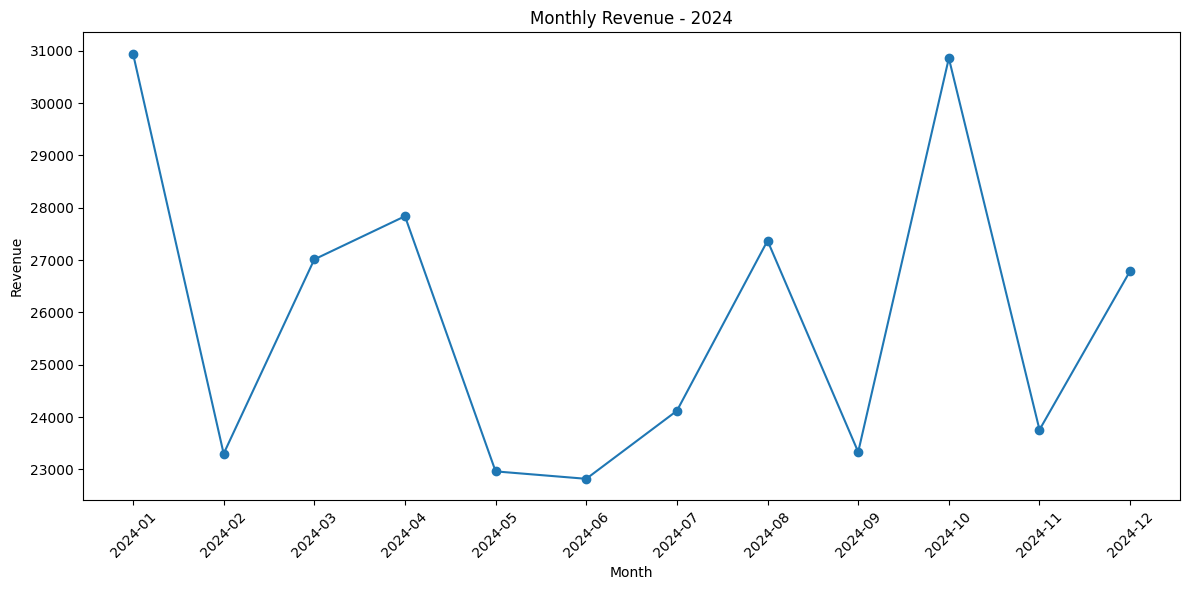

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['revenue'],
    marker='o'
)

plt.title('Monthly Revenue - 2024')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

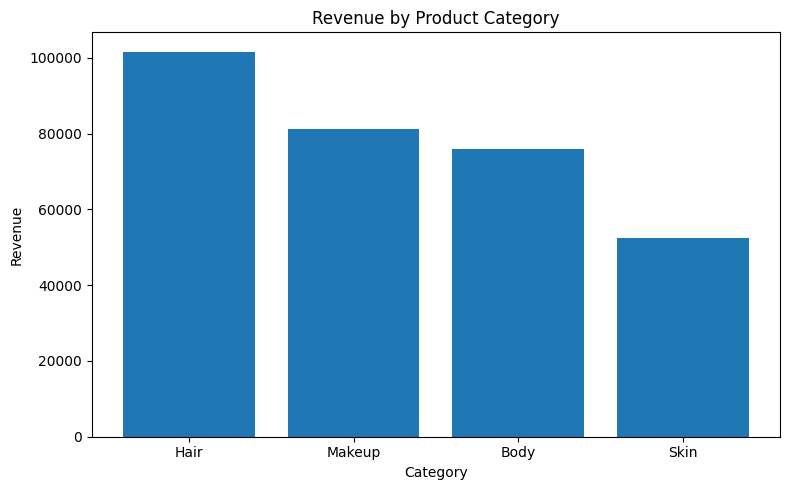

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis['category'],
    category_analysis['revenue']
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()

plt.show()

In [ ]:
sales = sales.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

top_products = (
    sales.groupby(['product_id', 'product_name'], as_index=False)
    .agg(revenue=('revenue', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(10)
)

top_products

,product_id,product_name,revenue
15,16,Product_16,9732
44,45,Product_45,9644
24,25,Product_25,9527
22,23,Product_23,9426
5,6,Product_6,8661
46,47,Product_47,8119
12,13,Product_13,8065
3,4,Product_4,7788
31,32,Product_32,7735
13,14,Product_14,7474


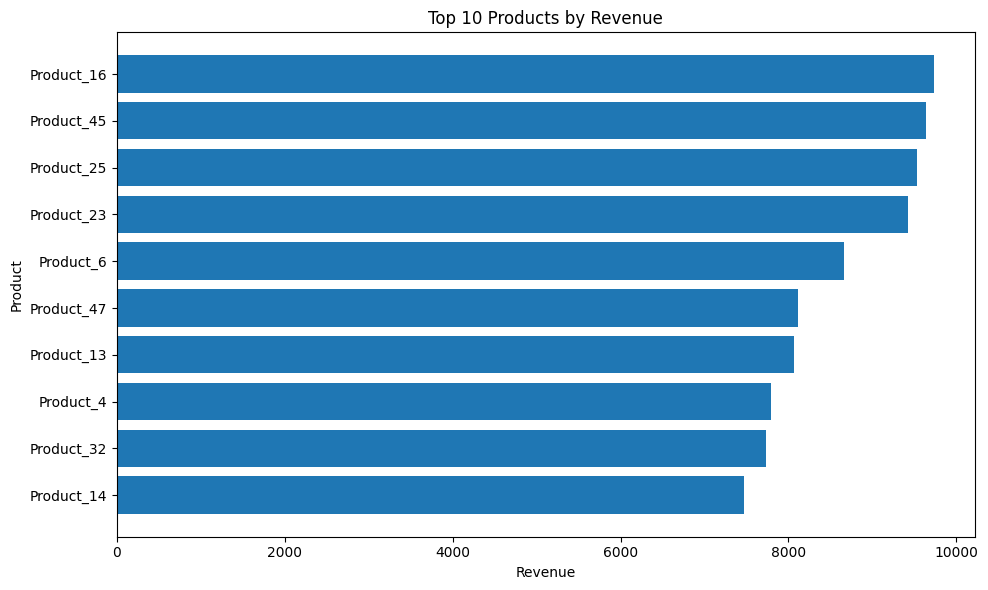

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products['product_name'],
    top_products['revenue']
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [ ]:
top_customers = (
    sales.groupby(['customer_id'], as_index=False)
    .agg(revenue=('revenue', 'sum'))
    .sort_values('revenue', ascending=False)
    .head(10)
)

top_customers

,customer_id,revenue
12,13,5048
34,39,4564
135,152,4309
127,144,3420
67,76,3330
97,113,2960
109,126,2960
113,130,2949
246,277,2939
208,231,2807


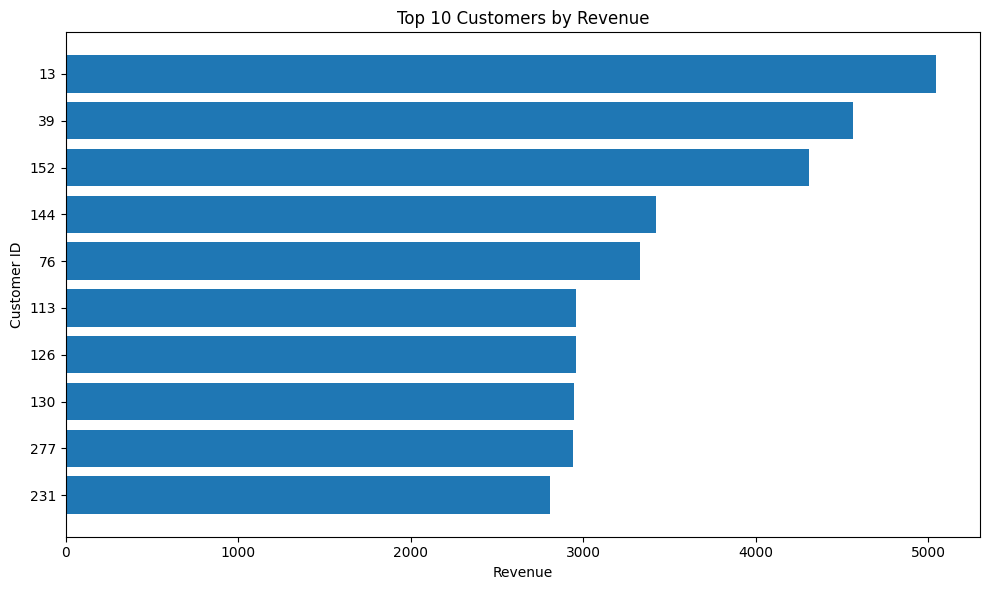

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers['customer_id'].astype(str),
    top_customers['revenue']
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [ ]:
sales = sales.merge(
    customers[['customer_id', 'country']],
    on='customer_id',
    how='left'
)

In [ ]:
country_revenue = (
    sales.groupby('country', as_index=False)
    .agg(revenue=('revenue', 'sum'))
    .sort_values('revenue', ascending=False)
)

country_revenue

,country,revenue
2,Italy,70719
4,Spain,69897
3,Morocco,65164
0,France,55976
1,Germany,49355


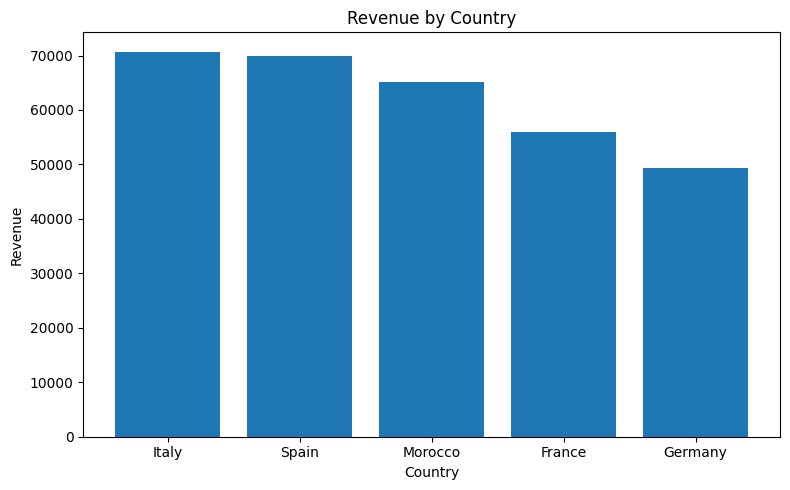

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    country_revenue['country'],
    country_revenue['revenue']
)

plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.tight_layout()

plt.show()